# Vectors and Vector Spaces

In [1]:
# initialize things up
from sklearn.datasets import load_iris 
data = load_iris() 
X, y = data["data"], data["target"] 
X[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

The row X cols in the arr represented as `X.shape` in numpy

In [2]:
X.shape
print(X.shape)
print(f"{X.shape[0]} rows\n{X.shape[1]} cols")

(150, 4)
150 rows
4 cols


In mathematical terms the dataset is a **Matrix** and the data points are vectors, eg: matrices are tables and vectors and tuples like ((1.297,−2.35,32.3,29.874))

The key important to have good predictions is to scale data

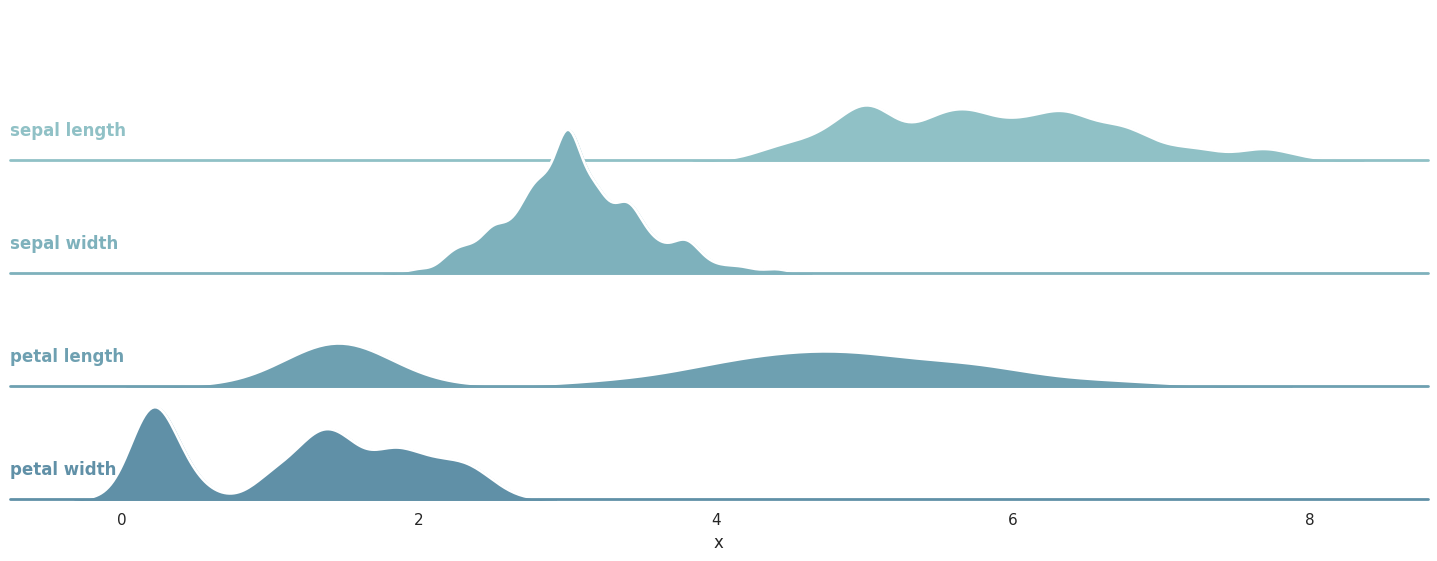

In [3]:
import pandas as pd 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the data
x = X.ravel()
labels = ["sepal length", "sepal width", "petal length", "petal width"]
g = np.tile(labels, len(X))
df = pd.DataFrame(dict(x=x, g=g))

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="g", hue="g", aspect=10, height=1.5, palette=pal)

# Draw the densities
g.map(sns.kdeplot, "x", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add reference line
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Label each plot
g.map(lambda x, color, label: plt.gca().text(0, .2, label, fontweight="bold", color=color,ha="left", va="center", transform=plt.gca().transAxes), "x")

# Adjust subplots and aesthetics
g.figure.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()

We can see that the `sepal width` and `petal width` have large scale than others, and this is a problem

to solve it we can remove the mean and the standard deviations of a the dataset

$$
\mu(mean) = \frac{1}{N} \sum^{N}_{i=1} x_i \in \mathbb{R}^c
$$

std

$$
\sigma(std) = \sqrt{\frac{1}{N} \sum^{N}_{i=1} (x_i - \mu)^2} \in \mathbb{R}^c
$$

In [4]:
X_scaled = (X - X.mean(axis=0))/X.std(axis=0)
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

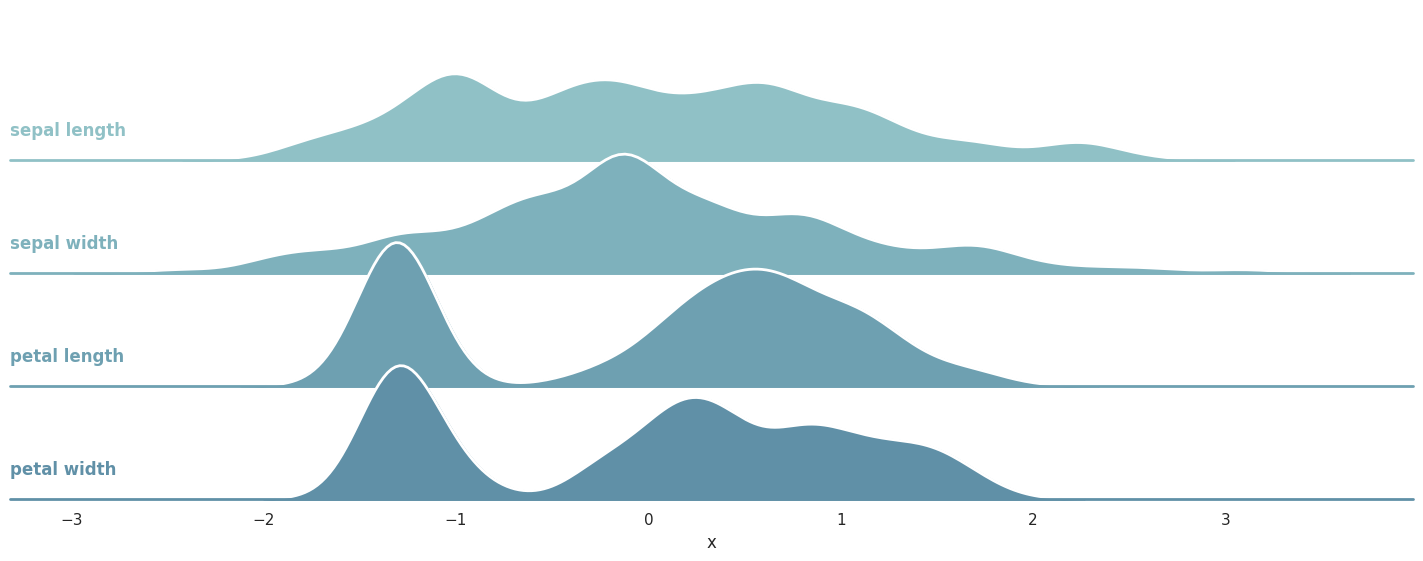

In [5]:
# Create the data
x = X_scaled.ravel()
labels = ["sepal length", "sepal width", "petal length", "petal width"]
g = np.tile(labels, X_scaled.shape[0])
df = pd.DataFrame(dict(x=x, g=g))

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
grid = sns.FacetGrid(df, row="g", hue="g", aspect=10, height=1.5, palette=pal)

# Draw the densities
grid.map(sns.kdeplot, "x", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
grid.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add reference line
grid.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Add labels to each plot
grid.map(lambda x, color, label: plt.gca().text(0, .2, label, fontweight="bold", color=color,ha="left", va="center", transform=plt.gca().transAxes), "x")

# Adjust subplots and aesthetics
grid.figure.subplots_adjust(hspace=-.25)
grid.set_titles("")
grid.set(yticks=[], ylabel="")
grid.despine(bottom=True, left=True)

plt.show()

## What is a vector space?

